In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vamsinossam/archeive/training.1600000.processed.noemoticon.csv


In [2]:
pip install pandas numpy matplotlib seaborn nltk wordcloud

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [4]:
df = pd.read_csv('/kaggle/input/datasets/vamsinossam/archeive/training.1600000.processed.noemoticon.csv',
                 encoding='latin-1',
                 header=None)

df.columns = ['sentiment','id','date','flag','user','text']

df.head()

,sentiment,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [5]:
df = df[['sentiment','text']]

In [6]:
df['sentiment'] = df['sentiment'].replace(4,1)

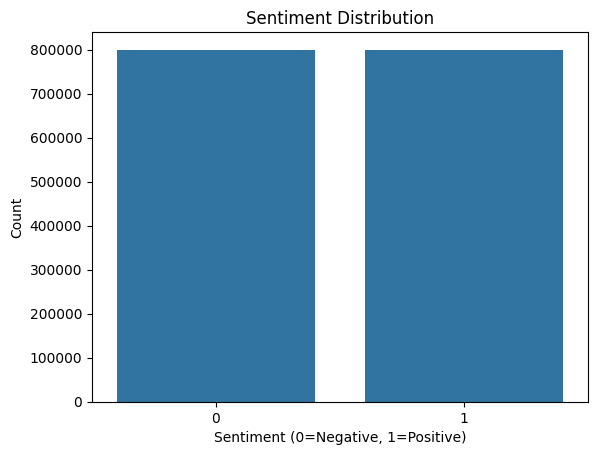

In [7]:
sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0=Negative, 1=Positive)")
plt.ylabel("Count")

plt.show()

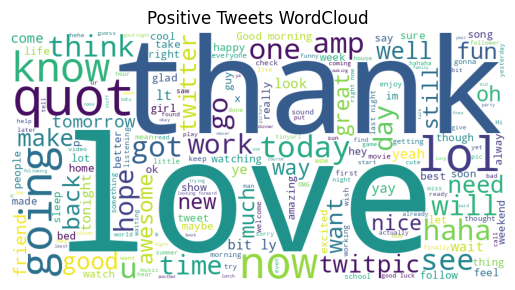

In [8]:
positive_text = " ".join(df[df['sentiment']==1]['text'])

wordcloud = WordCloud(width=800,height=400,
                      background_color='white').generate(positive_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Tweets WordCloud")

plt.show()

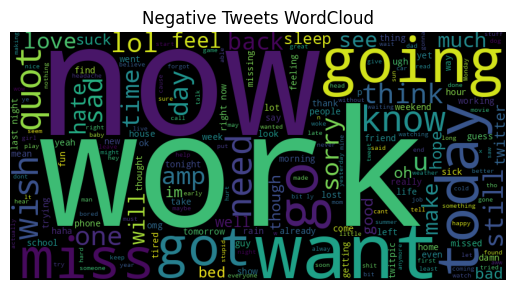

In [9]:
negative_text = " ".join(df[df['sentiment']==0]['text'])

wordcloud = WordCloud(width=800,height=400,
                      background_color='black').generate(negative_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Tweets WordCloud")

plt.show()

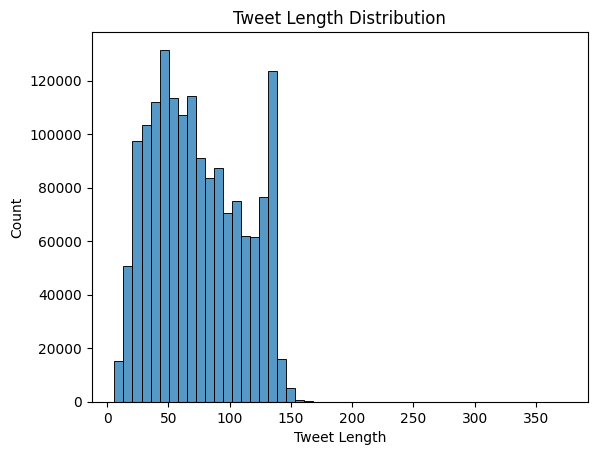

In [10]:
df['tweet_length'] = df['text'].apply(len)

sns.histplot(df['tweet_length'], bins=50)

plt.title("Tweet Length Distribution")
plt.xlabel("Tweet Length")

plt.show()

In [11]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [12]:
from textblob import TextBlob

df['polarity'] = df['text'].apply(lambda x: TextBlob(x).sentiment.polarity)

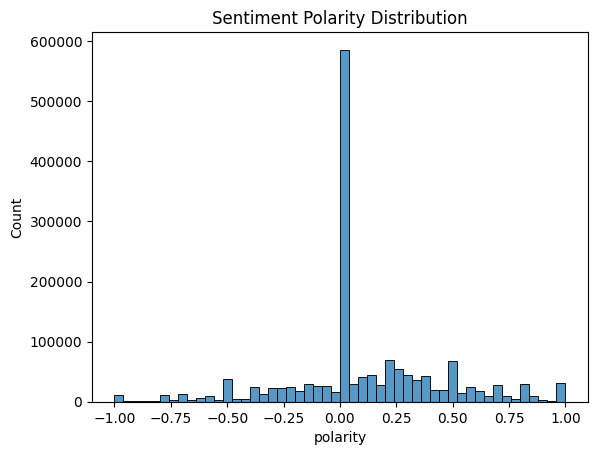

In [13]:
sns.histplot(df['polarity'], bins=50)

plt.title("Sentiment Polarity Distribution")

plt.show()